In [1]:
# =============================================================================
# 01_eda.ipynb – Explorative Datenanalyse
# Projekt: MSIT Mock Interview – Loan Status Klassifikation
# =============================================================================

# --- Standard Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Darstellungskonfiguration ---
pd.set_option("display.max_columns", None)   # alle Spalten anzeigen
pd.set_option("display.float_format", "{:.2f}".format)  # 2 Dezimalstellen

sns.set_theme(style="darkgrid")              # einheitliches Plot-Design
plt.rcParams["figure.figsize"] = (10, 6)    # Standard-Plotgröße

print("Libraries erfolgreich geladen.")

Libraries erfolgreich geladen.


In [2]:
# --- Datensatz laden ---
df = pd.read_csv("../data/raw/loans_modified.csv")

# --- Erste Übersicht ---
print(f"Shape: {df.shape}")
print(f"\nSpalten:\n{df.columns.tolist()}")
print(f"\nErste 5 Zeilen:")
df.head()

Shape: (563, 13)

Spalten:
['loan_id', 'gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term', 'credit_history', 'property_area', 'loan_status']

Erste 5 Zeilen:


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001003,Male,Yes,1,Graduate,No,4583.00,1508.00,128.00,360.00,1.00,Rural,0.00
1,LP001005,Male,Yes,0,Graduate,NaN,3000.00,0.00,66.00,360.00,1.00,Urban,1.00
2,LP001006,Male,Yes,0,Not Graduate,No,2583.00,2358.00,120.00,360.00,1.00,Urban,1.00
3,LP001008,Male,No,0,Graduate,No,6000.00,0.00,141.00,360.00,1.00,Urban,1.00
4,LP001011,Male,Yes,2,Graduate,Yes,5417.00,4196.00,267.00,360.00,1.00,Urban,1.00


In [3]:
# --- Datentypen & Grundstruktur ---
print("=== Datentypen ===")
print(df.dtypes)

print("\n=== Grundlegende Statistiken ===")
df.describe(include="all")


=== Datentypen ===
loan_id                   str
gender                    str
married                   str
dependents                str
education                 str
self_employed             str
applicant_income      float64
coapplicant_income    float64
loan_amount           float64
loan_amount_term      float64
credit_history        float64
property_area             str
loan_status           float64
dtype: object

=== Grundlegende Statistiken ===


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
count,534,534,544,531,541,529,537.00,529.00,533.00,535.00,541.00,542,535.00
unique,512,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,NaN
top,LP001032,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,NaN
freq,2,433,348,307,426,461,NaN,NaN,NaN,NaN,NaN,212,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,5379.37,1692.60,147.43,341.67,0.88,NaN,0.72
std,NaN,NaN,NaN,NaN,NaN,NaN,6064.81,3093.38,85.85,65.30,0.33,NaN,0.45
min,NaN,NaN,NaN,NaN,NaN,NaN,150.00,0.00,9.00,12.00,0.00,NaN,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,2894.00,0.00,100.00,360.00,1.00,NaN,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,3762.00,1250.00,128.00,360.00,1.00,NaN,1.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,5818.00,2333.00,172.00,360.00,1.00,NaN,1.00


In [4]:
# --- Fehlende Werte ---
missing = pd.DataFrame({
    "Fehlend (absolut)": df.isnull().sum(),
    "Fehlend (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Fehlend (absolut)"] > 0].sort_values(
    "Fehlend (%)", ascending=False
)

print(missing)

                    Fehlend (absolut)  Fehlend (%)
self_employed                      34         6.04
coapplicant_income                 34         6.04
dependents                         32         5.68
loan_amount                        30         5.33
loan_id                            29         5.15
gender                             29         5.15
loan_amount_term                   28         4.97
loan_status                        28         4.97
applicant_income                   26         4.62
credit_history                     22         3.91
education                          22         3.91
property_area                      21         3.73
married                            19         3.37


In [5]:
# --- Zielvariable: loan_status ---
print("=== loan_status Verteilung (inkl. NaN) ===")
print(df["loan_status"].value_counts(dropna=False))

print(f"\n=== Klassenverteilung (%) ===")
print(df["loan_status"].value_counts(normalize=True, dropna=True).mul(100).round(2))

=== loan_status Verteilung (inkl. NaN) ===
loan_status
1.00    384
0.00    151
NaN      28
Name: count, dtype: int64

=== Klassenverteilung (%) ===
loan_status
1.00   71.78
0.00   28.22
Name: proportion, dtype: float64


In [6]:
# --- Kategorische Features ---
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [col for col in cat_cols if col != "loan_id"]

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== gender ===
gender
Male      433
Female    101
NaN        29
Name: count, dtype: int64

=== married ===
married
Yes    348
No     196
NaN     19
Name: count, dtype: int64

=== dependents ===
dependents
0      307
1       93
2       88
3+      43
NaN     32
Name: count, dtype: int64

=== education ===
education
Graduate        426
Not Graduate    115
NaN              22
Name: count, dtype: int64

=== self_employed ===
self_employed
No     461
Yes     68
NaN     34
Name: count, dtype: int64

=== property_area ===
property_area
Semiurban    212
Urban        175
Rural        155
NaN           21
Name: count, dtype: int64


C:\Users\erikg\AppData\Local\Temp\ipykernel_10788\4287129059.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [7]:
# --- Numerische Features (Pandas 4 kompatibel) ---
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_cols = [col for col in num_cols if col != "loan_status"]

print(f"Numerische Features: {num_cols}\n")
df[num_cols].describe()

Numerische Features: ['applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term', 'credit_history']



,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history
count,537.00,529.00,533.00,535.00,541.00
mean,5379.37,1692.60,147.43,341.67,0.88
std,6064.81,3093.38,85.85,65.30,0.33
min,150.00,0.00,9.00,12.00,0.00
25%,2894.00,0.00,100.00,360.00,1.00
50%,3762.00,1250.00,128.00,360.00,1.00
75%,5818.00,2333.00,172.00,360.00,1.00
max,81000.00,41667.00,650.00,480.00,1.00


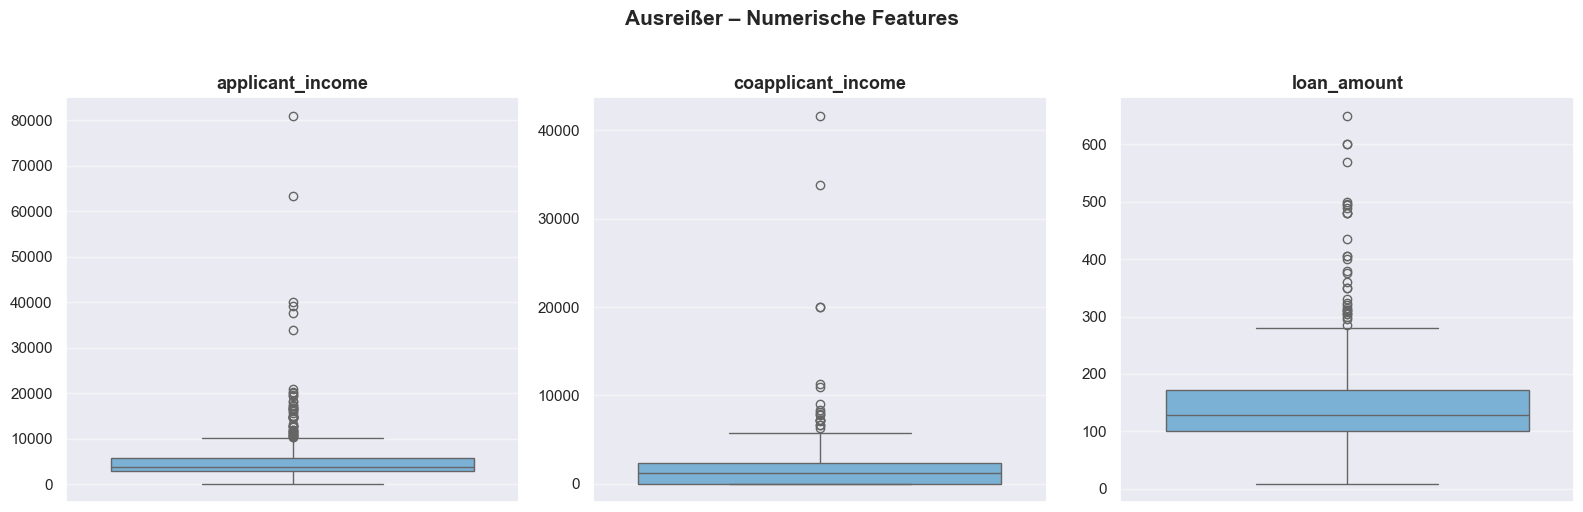

Plot gespeichert: reports/figures/01_boxplots_outliers.png


In [8]:
# --- Ausreißer visualisieren: Boxplots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["applicant_income", "coapplicant_income", "loan_amount"]):
    sns.boxplot(y=df[col], ax=ax, color="#6CB4E4")
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("")

plt.suptitle("Ausreißer – Numerische Features", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/01_boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: reports/figures/01_boxplots_outliers.png")

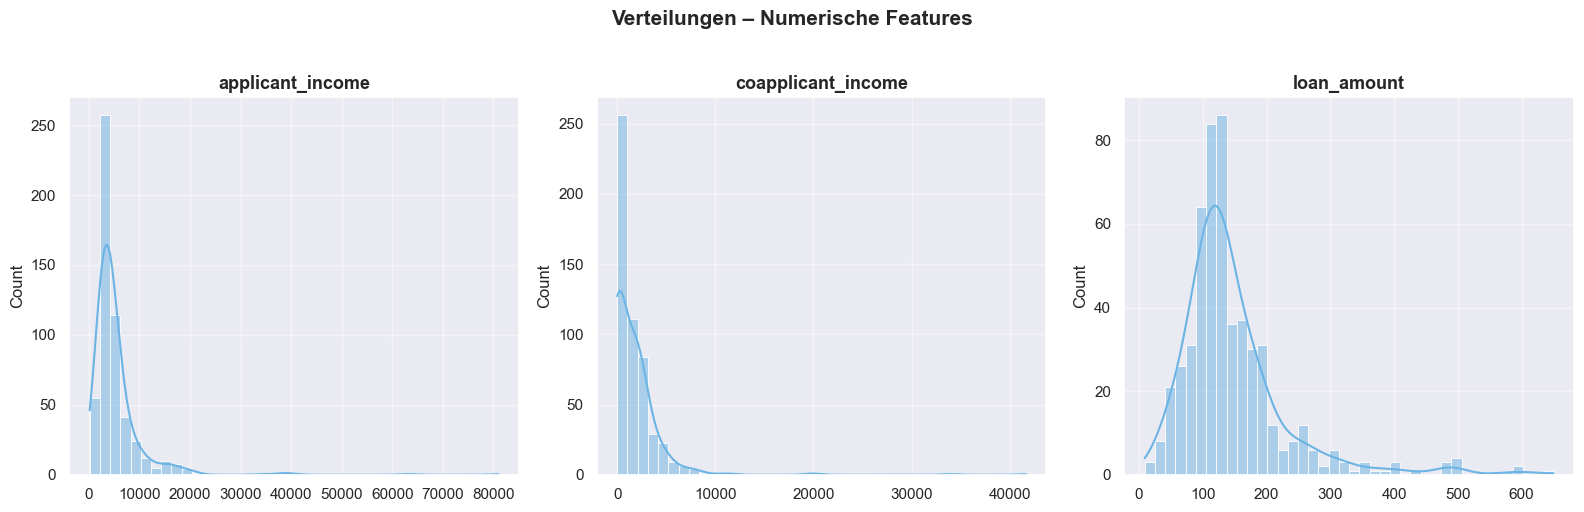

Plot gespeichert: reports/figures/02_histograms.png


In [9]:
# --- Verteilungen: Histogramme ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["applicant_income", "coapplicant_income", "loan_amount"]):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax, color="#6CB4E4")
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Verteilungen – Numerische Features", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/02_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: reports/figures/02_histograms.png")

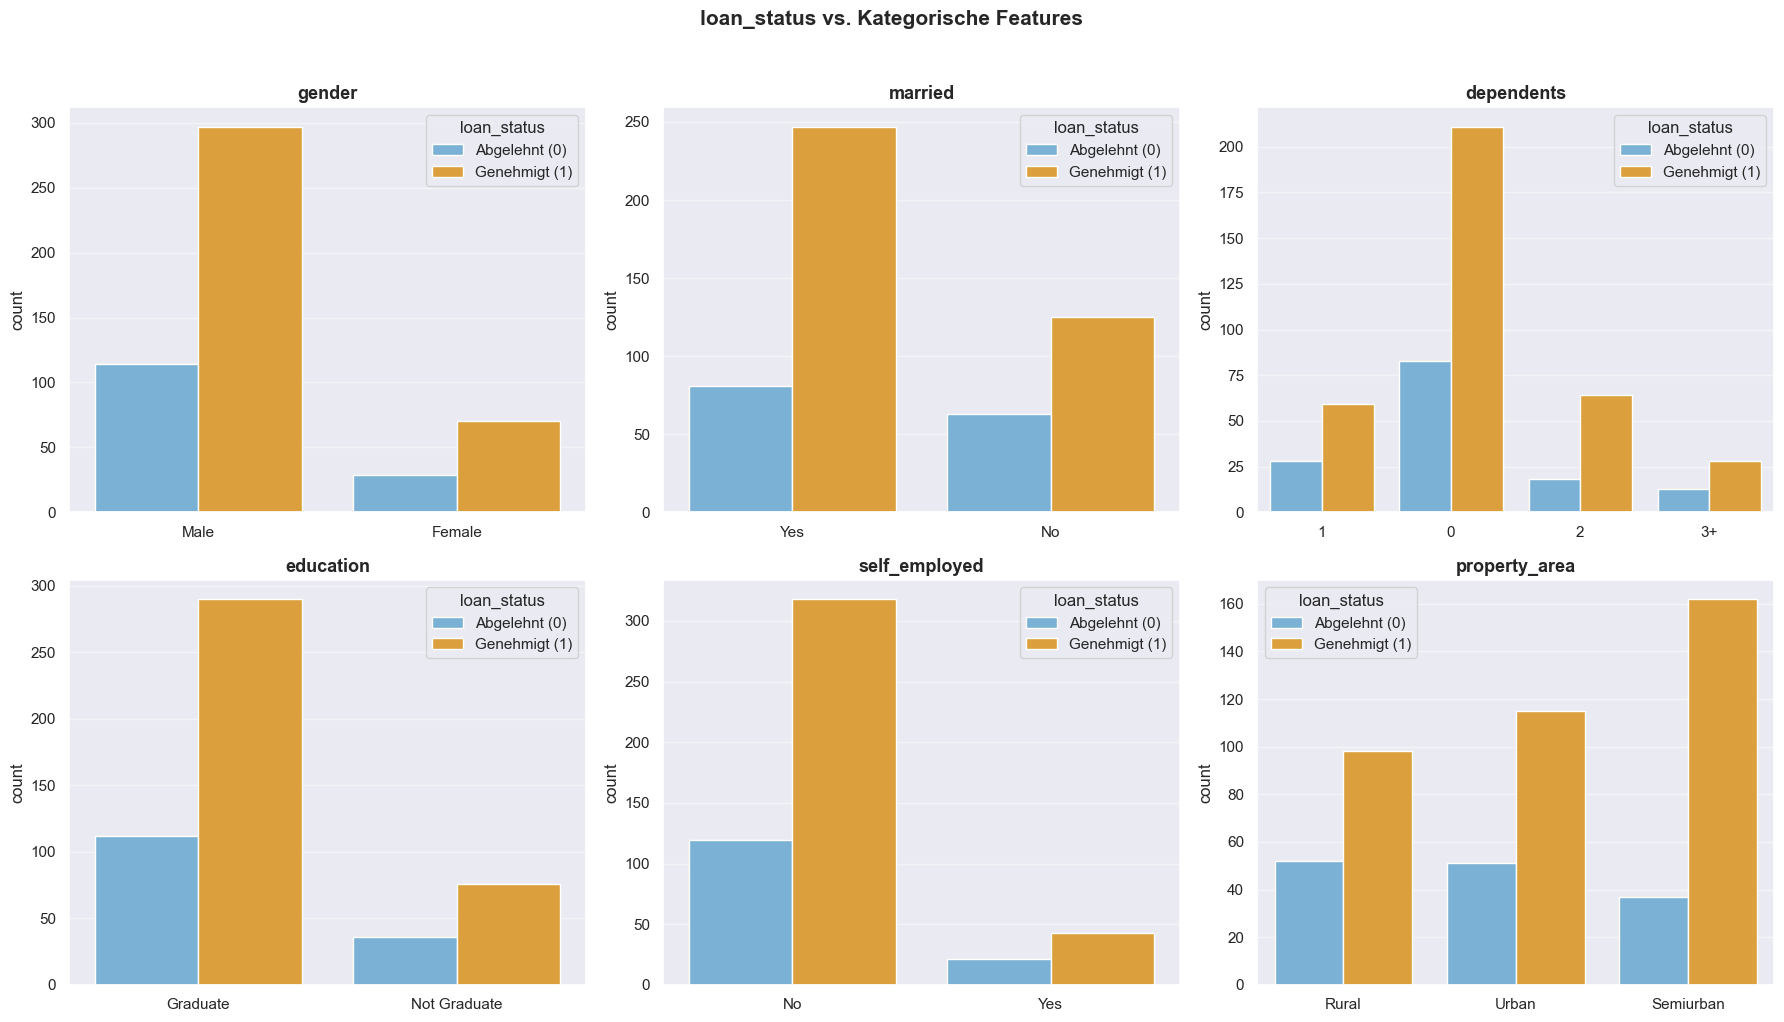

Plot gespeichert: reports/figures/03_categorical_vs_target.png


In [10]:
# --- loan_status vs. kategorische Features ---
cat_cols = ["gender", "married", "dependents", "education", "self_employed", "property_area"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    temp = df.dropna(subset=["loan_status", col])
    sns.countplot(
        data=temp,
        x=col,
        hue="loan_status",
        ax=ax,
        palette={0.0: "#6CB4E4", 1.0: "#F5A623"}
    )
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(title="loan_status", labels=["Abgelehnt (0)", "Genehmigt (1)"])

plt.suptitle("loan_status vs. Kategorische Features", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/03_categorical_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: reports/figures/03_categorical_vs_target.png")

In [11]:
# --- Genehmigungsrate pro kategorisches Feature ---
cat_cols = ["gender", "married", "dependents", "education", "self_employed", "property_area"]

for col in cat_cols:
    temp = df.dropna(subset=["loan_status", col])
    rate = (
        temp.groupby(col)["loan_status"]
        .agg(
            Genehmigt=lambda x: (x == 1.0).sum(),
            Abgelehnt=lambda x: (x == 0.0).sum(),
            Gesamt="count"
        )
    )
    rate["Genehmigungsrate (%)"] = (rate["Genehmigt"] / rate["Gesamt"] * 100).round(2)
    rate = rate.sort_values("Genehmigungsrate (%)", ascending=False)

    print(f"\n=== {col} ===")
    print(rate.to_string())
    print("-" * 50)


=== gender ===
        Genehmigt  Abgelehnt  Gesamt  Genehmigungsrate (%)
gender                                                    
Male          297        114     411                 72.26
Female         70         29      99                 70.71
--------------------------------------------------

=== married ===
         Genehmigt  Abgelehnt  Gesamt  Genehmigungsrate (%)
married                                                    
Yes            247         81     328                 75.30
No             125         63     188                 66.49
--------------------------------------------------

=== dependents ===
            Genehmigt  Abgelehnt  Gesamt  Genehmigungsrate (%)
dependents                                                    
2                  64         18      82                 78.05
0                 211         83     294                 71.77
3+                 28         13      41                 68.29
1                  59         28      87              

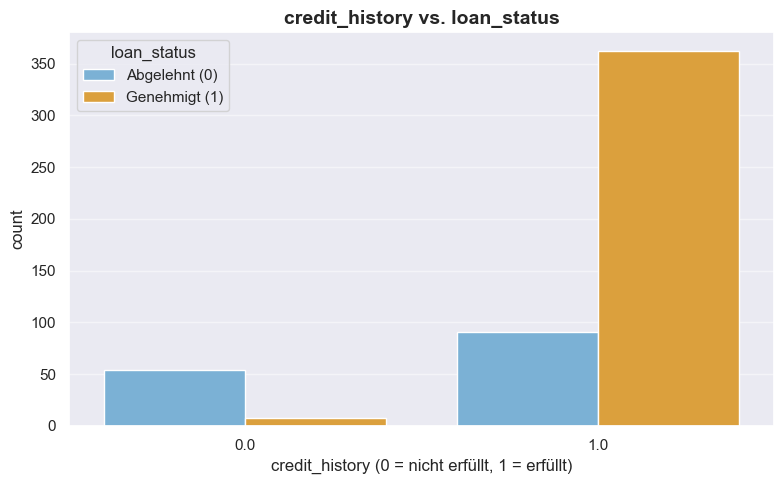

Plot gespeichert: reports/figures/04_credit_history_vs_target.png


In [12]:
# --- credit_history vs. loan_status (wichtigstes Feature) ---
temp = df.dropna(subset=["loan_status", "credit_history"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=temp,
    x="credit_history",
    hue="loan_status",
    palette={0.0: "#6CB4E4", 1.0: "#F5A623"},
    ax=ax
)
ax.set_title("credit_history vs. loan_status", fontsize=14, fontweight="bold")
ax.set_xlabel("credit_history (0 = nicht erfüllt, 1 = erfüllt)")
ax.legend(title="loan_status", labels=["Abgelehnt (0)", "Genehmigt (1)"])

plt.tight_layout()
plt.savefig("../reports/figures/04_credit_history_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: reports/figures/04_credit_history_vs_target.png")

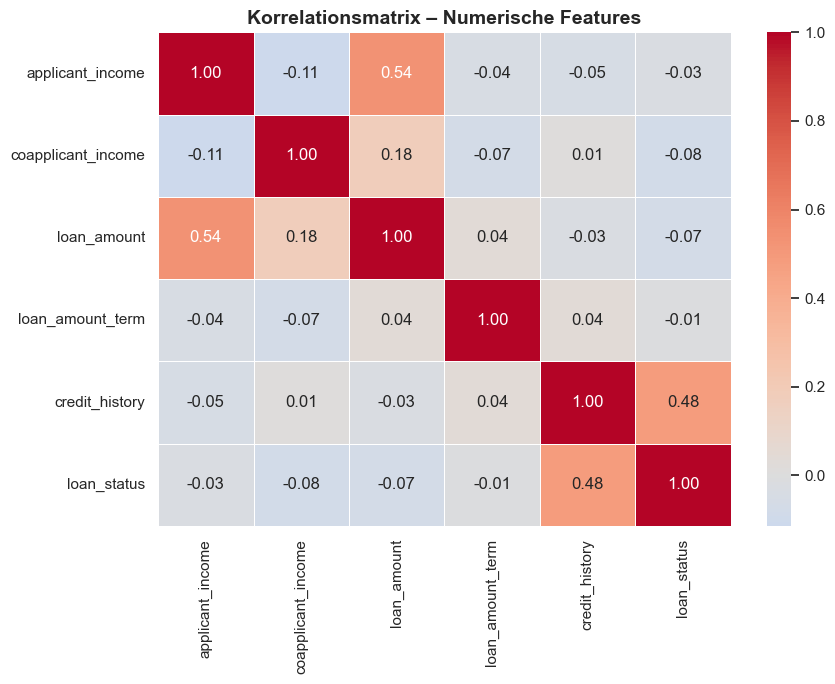

Plot gespeichert: reports/figures/05_correlation_matrix.png


In [13]:
# --- Korrelationsmatrix (nur numerische Features) ---
num_cols = ["applicant_income", "coapplicant_income", "loan_amount",
            "loan_amount_term", "credit_history", "loan_status"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Korrelationsmatrix – Numerische Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/05_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: reports/figures/05_correlation_matrix.png")

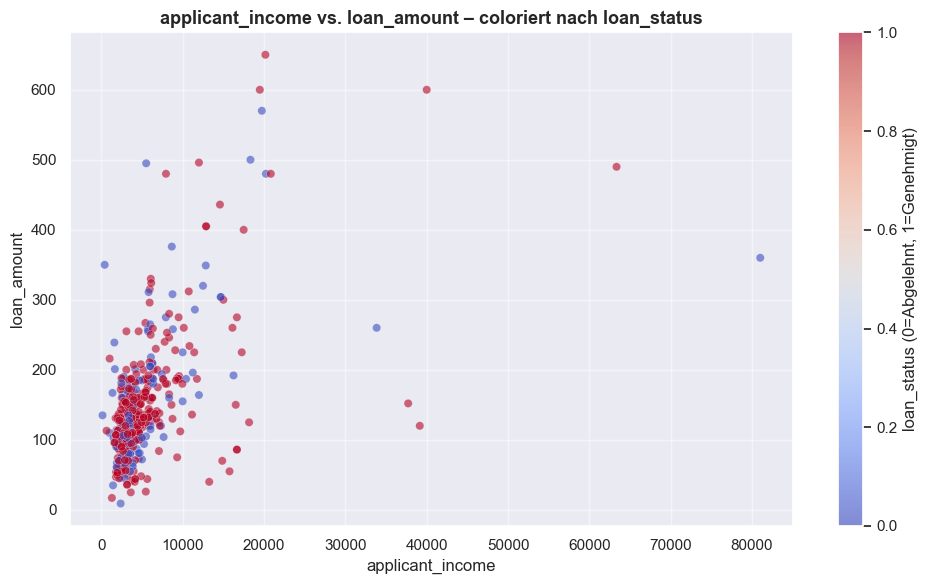

Plot gespeichert: reports/figures/06_scatter_income_loanamount.png


In [14]:
# --- Scatter: applicant_income vs. loan_amount ---
fig, ax = plt.subplots(figsize=(10, 6))

temp = df.dropna(subset=["applicant_income", "loan_amount", "loan_status"])

scatter = ax.scatter(
    temp["applicant_income"],
    temp["loan_amount"],
    c=temp["loan_status"],
    cmap="coolwarm",
    alpha=0.6,
    edgecolors="white",
    linewidths=0.3
)

plt.colorbar(scatter, ax=ax, label="loan_status (0=Abgelehnt, 1=Genehmigt)")
ax.set_xlabel("applicant_income", fontsize=12)
ax.set_ylabel("loan_amount", fontsize=12)
ax.set_title("applicant_income vs. loan_amount – coloriert nach loan_status",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/06_scatter_income_loanamount.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: reports/figures/06_scatter_income_loanamount.png")

In [15]:
# =============================================================================
# Zelle 14 – Erweiterte Imports für professionelle EDA
# =============================================================================

# --- Standard ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Statistik ---
from scipy import stats
from scipy.stats import (
    shapiro,          # Normalverteilungstest
    chi2_contingency, # Chi-Quadrat Test
    kruskal,          # Kruskal-Wallis Test (non-parametric ANOVA)
    pointbiserialr,   # Point-Biserial Korrelation
    boxcox,           # Box-Cox Transformation
    yeojohnson        # Yeo-Johnson Transformation
)
from sklearn.feature_selection import mutual_info_classif  # Mutual Information
from unidip import dip                                     # Hartigan Dip Test

# --- Ausgabepfade sicherstellen ---
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
Path("../reports/eda_csv").mkdir(parents=True, exist_ok=True)

print("✅ Alle Packages erfolgreich geladen.")

✅ Alle Packages erfolgreich geladen.


In [16]:
# =============================================================================
# Zelle 15 – Univariate Analyse: Numerische Features
# Metriken: Skewness, Kurtosis, Shapiro-Wilk, Dip Test, IQR Outlier, Yeo-Johnson
# =============================================================================

def hartigan_dip_test(data: np.ndarray) -> float:
    """
    Vereinfachter Dip-Statistik Schätzer.
    Misst maximale Abweichung der ECDF von der nächsten Unimodalen.
    Höherer Wert → stärkerer Hinweis auf Multimodalität.
    """
    data = np.sort(data)
    n    = len(data)
    ecdf = np.arange(1, n + 1) / n
    uniform = np.linspace(0, 1, n)
    return float(np.max(np.abs(ecdf - uniform)))


num_cols = ["applicant_income", "coapplicant_income", "loan_amount",
            "loan_amount_term", "credit_history"]

results = []

for col in num_cols:
    series = df[col].dropna()

    # --- Grundstatistiken ---
    skewness = series.skew()
    kurtosis = series.kurtosis()  # Excess Kurtosis (Normalverteilung = 0)

    # --- Shapiro-Wilk Test ---
    stat_sw, p_sw = shapiro(series.sample(min(len(series), 500), random_state=42))

    # --- Hartigan Dip Test ---
    dip_stat = hartigan_dip_test(series.values)

    # --- IQR Outlier Count ---
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    n_out  = int(((series < lower) | (series > upper)).sum())

    # --- Yeo-Johnson Lambda ---
    _, lam_yj = yeojohnson(series)

    results.append({
        "Feature":            col,
        "N":                  len(series),
        "Mean":               round(series.mean(), 2),
        "Std":                round(series.std(), 2),
        "Min":                round(series.min(), 2),
        "Max":                round(series.max(), 2),
        "Skewness":           round(skewness, 4),
        "Skew Interpretation":("Stark rechtsschief" if skewness > 1
                               else "Stark linksschief" if skewness < -1
                               else "Moderat schief" if abs(skewness) > 0.5
                               else "Annähernd symmetrisch"),
        "Kurtosis (Excess)":  round(kurtosis, 4),
        "Kurt Interpretation":("Leptokurtisch (schwere Tails)" if kurtosis > 1
                               else "Platykurtisch (leichte Tails)" if kurtosis < -1
                               else "Mesokurtisch (normal)"),
        "Shapiro-Wilk Stat":  round(stat_sw, 4),
        "Shapiro-Wilk p":     round(p_sw, 6),
        "Normalverteilt?":    "Ja" if p_sw > 0.05 else "Nein",
        "Dip Stat":           round(dip_stat, 6),
        "Multimodal?":        "Möglich" if dip_stat > 0.05 else "Unimodal",
        "IQR Lower":          round(lower, 2),
        "IQR Upper":          round(upper, 2),
        "N Outliers (IQR)":   n_out,
        "Outlier %":          round(n_out / len(series) * 100, 2),
        "Yeo-Johnson Lambda": round(lam_yj, 4),
    })

df_num_uni = pd.DataFrame(results)

# --- CSV speichern ---
df_num_uni.to_csv("../reports/eda_csv/eda_numeric_univariate.csv", index=False)

print("✅ CSV gespeichert: reports/eda_csv/eda_numeric_univariate.csv\n")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df_num_uni.to_string(index=False))

✅ CSV gespeichert: reports/eda_csv/eda_numeric_univariate.csv

           Feature   N    Mean     Std    Min      Max  Skewness Skew Interpretation  Kurtosis (Excess)           Kurt Interpretation  Shapiro-Wilk Stat  Shapiro-Wilk p Normalverteilt?  Dip Stat Multimodal?  IQR Lower  IQR Upper  N Outliers (IQR)  Outlier %  Yeo-Johnson Lambda
  applicant_income 537 5379.37 6064.81 150.00 81000.00      6.74  Stark rechtsschief              65.34 Leptokurtisch (schwere Tails)               0.47            0.00            Nein      0.00    Unimodal   -1492.00   10204.00                46       8.57               -0.09
coapplicant_income 529 1692.60 3093.38   0.00 41667.00      7.30  Stark rechtsschief              78.20 Leptokurtisch (schwere Tails)               0.47            0.00            Nein      0.00    Unimodal   -3499.50    5832.50                18       3.40                0.07
       loan_amount 533  147.43   85.85   9.00   650.00      2.43  Stark rechtsschief               8.36

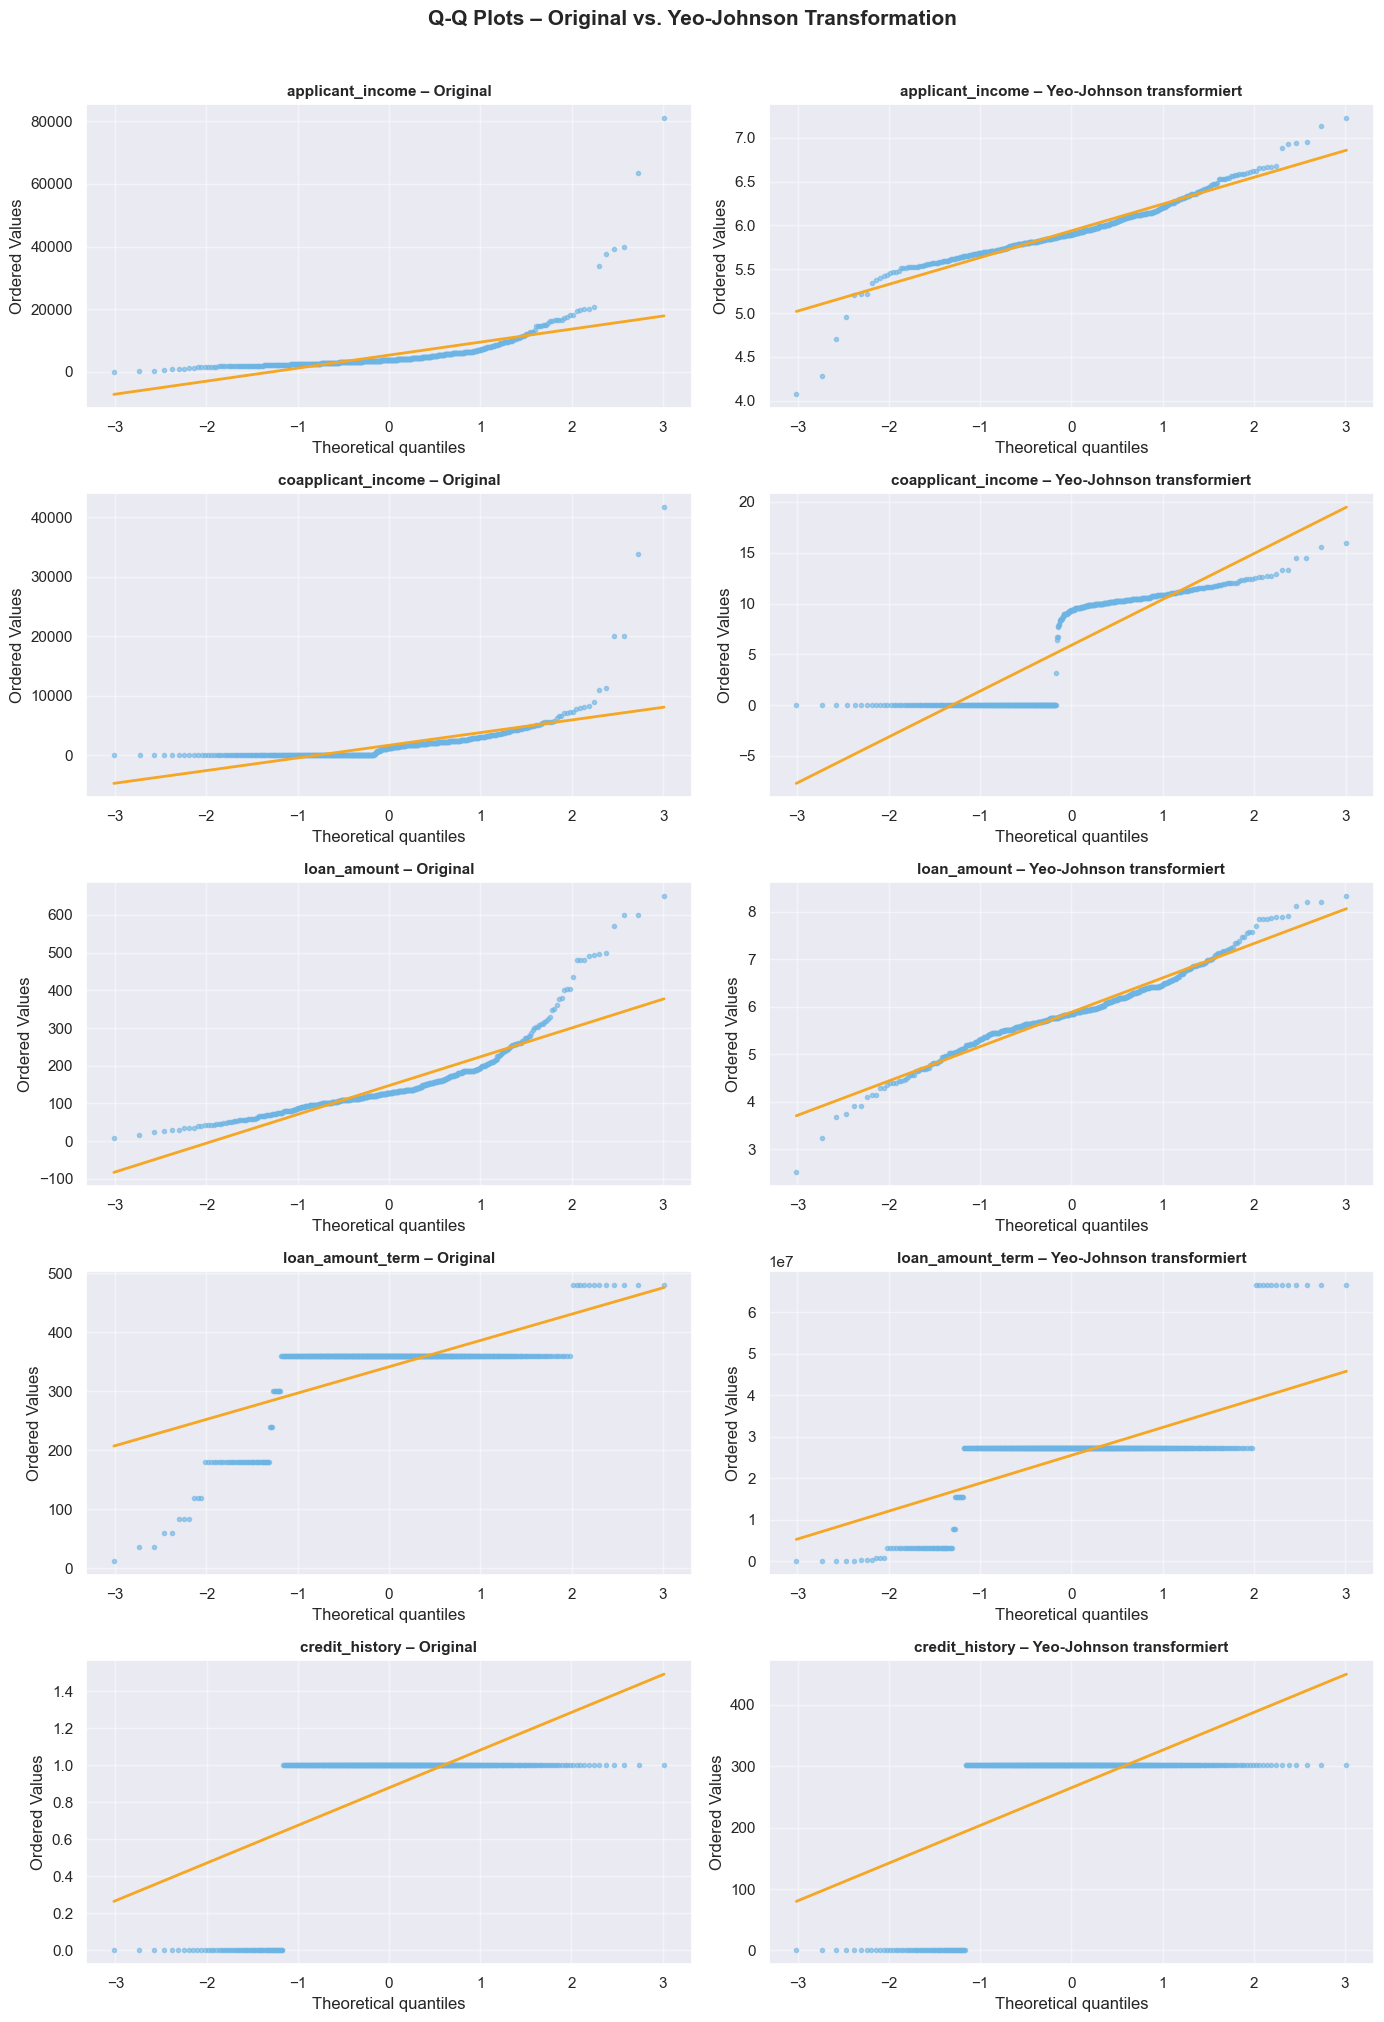

✅ Plot gespeichert: reports/figures/07_qq_plots_grid.png


In [17]:
# =============================================================================
# Zelle 16 – Q-Q Plots: Normalverteilungsabweichung visuell
# Ein Grid mit Original + Yeo-Johnson transformiert pro Feature
# =============================================================================

num_cols = ["applicant_income", "coapplicant_income", "loan_amount",
            "loan_amount_term", "credit_history"]

fig, axes = plt.subplots(
    nrows=len(num_cols),
    ncols=2,
    figsize=(14, len(num_cols) * 4)
)

for i, col in enumerate(num_cols):
    series = df[col].dropna().values

    # --- Original Q-Q Plot ---
    ax_orig = axes[i, 0]
    stats.probplot(series, dist="norm", plot=ax_orig)
    ax_orig.set_title(f"{col} – Original", fontsize=11, fontweight="bold")
    ax_orig.get_lines()[0].set(color="#6CB4E4", markersize=3, alpha=0.6)
    ax_orig.get_lines()[1].set(color="#F5A623", linewidth=2)

    # --- Yeo-Johnson transformiert Q-Q Plot ---
    ax_trans = axes[i, 1]
    transformed, _ = yeojohnson(series)
    stats.probplot(transformed, dist="norm", plot=ax_trans)
    ax_trans.set_title(f"{col} – Yeo-Johnson transformiert", fontsize=11, fontweight="bold")
    ax_trans.get_lines()[0].set(color="#6CB4E4", markersize=3, alpha=0.6)
    ax_trans.get_lines()[1].set(color="#F5A623", linewidth=2)

plt.suptitle("Q-Q Plots – Original vs. Yeo-Johnson Transformation",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/07_qq_plots_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/07_qq_plots_grid.png")

In [18]:
# =============================================================================
# Zelle 17 – Univariate Analyse: Kategorische Features
# Metriken: Kardinalität, Dominanz, Imbalance Ratio, Entropie,
#           Chi-Quadrat Test, Cramér's V
# =============================================================================

def cramers_v(col: pd.Series, target: pd.Series) -> float:
    """
    Cramér's V – Stärke des Zusammenhangs zwischen
    kategorischem Feature und binärer Zielvariable.
    Wertebereich: 0 (kein Zusammenhang) – 1 (perfekter Zusammenhang)
    """
    confusion = pd.crosstab(col, target)
    chi2, _, _, _ = chi2_contingency(confusion)
    n = confusion.sum().sum()
    r, k = confusion.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return float(v)


def entropy(series: pd.Series) -> float:
    """
    Shannon Entropie – Informationsgehalt der Verteilung.
    Niedrige Entropie → wenig Varianz, hohes Dominanzproblem.
    """
    probs = series.value_counts(normalize=True)
    return float(-np.sum(probs * np.log2(probs + 1e-10)))


cat_cols = ["gender", "married", "dependents", "education",
            "self_employed", "property_area"]

# Zielvariable – NaN entfernen
target = df["loan_status"].dropna()

results = []

for col in cat_cols:
    # Nur Zeilen ohne NaN in Feature UND Zielvariable
    temp = df[[col, "loan_status"]].dropna()
    series = temp[col]
    tgt    = temp["loan_status"]

    # --- Kardinalität ---
    n_unique = series.nunique()

    # --- Dominanzindex ---
    top_freq  = series.value_counts(normalize=True).iloc[0]
    top_cat   = series.value_counts().index[0]

    # --- Imbalance Ratio ---
    counts        = series.value_counts()
    imbalance     = counts.iloc[0] / counts.iloc[-1]

    # --- Entropie ---
    ent = entropy(series)
    max_ent = np.log2(n_unique)  # maximale Entropie bei gleichverteilung

    # --- Chi-Quadrat Test ---
    confusion = pd.crosstab(series, tgt)
    chi2_stat, chi2_p, chi2_dof, _ = chi2_contingency(confusion)

    # --- Cramér's V ---
    cv = cramers_v(series, tgt)

    results.append({
        "Feature":              col,
        "N":                    len(series),
        "Kardinalität":         n_unique,
        "Top Kategorie":        top_cat,
        "Dominanzindex":        round(top_freq, 4),
        "Dominanz %":           round(top_freq * 100, 2),
        "Imbalance Ratio":      round(imbalance, 2),
        "Entropie":             round(ent, 4),
        "Max Entropie":         round(max_ent, 4),
        "Entropie / Max":       round(ent / max_ent, 4),
        "Chi2 Stat":            round(chi2_stat, 4),
        "Chi2 p-Wert":          round(chi2_p, 6),
        "Chi2 dof":             chi2_dof,
        "Unabhängig? (p>0.05)": "Ja" if chi2_p > 0.05 else "Nein",
        "Cramér's V":           round(cv, 4),
        "Assoziation":          ("Stark"    if cv > 0.3 else
                                 "Moderat"  if cv > 0.1 else
                                 "Schwach"),
    })

df_cat_uni = pd.DataFrame(results)

# --- CSV speichern ---
df_cat_uni.to_csv("../reports/eda_csv/eda_categorical_univariate.csv", index=False)

print("✅ CSV gespeichert: reports/eda_csv/eda_categorical_univariate.csv\n")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df_cat_uni.to_string(index=False))

✅ CSV gespeichert: reports/eda_csv/eda_categorical_univariate.csv

      Feature   N  Kardinalität Top Kategorie  Dominanzindex  Dominanz %  Imbalance Ratio  Entropie  Max Entropie  Entropie / Max  Chi2 Stat  Chi2 p-Wert  Chi2 dof Unabhängig? (p>0.05)  Cramér's V Assoziation
       gender 510             2          Male           0.81       80.59             4.15      0.71          1.00            0.71       0.03         0.85         1                   Ja        0.01     Schwach
      married 516             2           Yes           0.64       63.57             1.74      0.95          1.00            0.95       4.19         0.04         1                 Nein        0.09     Schwach
   dependents 504             4             0           0.58       58.33             7.17      1.61          2.00            0.81       2.51         0.47         3                   Ja        0.07     Schwach
    education 514             2      Graduate           0.78       78.21             3.59      0.

In [19]:
# =============================================================================
# Zelle 18 – Missing Value Pattern Analyse
# Ziel: Sind fehlende Werte zufällig (MCAR) oder systematisch (MAR/MNAR)?
# =============================================================================

# --- 18a: Missing Value Übersicht ---
missing_stats = pd.DataFrame({
    "N Missing":    df.isnull().sum(),
    "Missing %":    (df.isnull().sum() / len(df) * 100).round(2),
    "N Valid":      df.notnull().sum(),
    "Dtype":        df.dtypes.astype(str),
}).sort_values("Missing %", ascending=False)

# --- MCAR/MAR Hinweis ---
# Strategie: prüfen ob Missingness in einer Spalte
# mit Missingness in einer anderen Spalte korreliert
# Hohe Korrelation → MAR (Missing At Random – systematisch)
# Keine Korrelation → MCAR (Missing Completely At Random – zufällig)

missing_indicator = df.isnull().astype(int)
missing_corr = missing_indicator.corr()

# --- Nur Spalten mit fehlenden Werten ---
missing_cols = missing_stats[missing_stats["N Missing"] > 0].index.tolist()
missing_indicator_sub = missing_indicator[missing_cols]
missing_corr_sub = missing_indicator_sub.corr()

# --- CSV speichern ---
missing_stats.to_csv("../reports/eda_csv/eda_missing_pattern.csv")
missing_corr_sub.round(4).to_csv("../reports/eda_csv/eda_missing_correlation.csv")

print("✅ CSV gespeichert:")
print("   reports/eda_csv/eda_missing_pattern.csv")
print("   reports/eda_csv/eda_missing_correlation.csv")
print()
print("=== Missing Value Übersicht ===")
print(missing_stats.to_string())

✅ CSV gespeichert:
   reports/eda_csv/eda_missing_pattern.csv
   reports/eda_csv/eda_missing_correlation.csv

=== Missing Value Übersicht ===
                    N Missing  Missing %  N Valid    Dtype
self_employed              34       6.04      529      str
coapplicant_income         34       6.04      529  float64
dependents                 32       5.68      531      str
loan_amount                30       5.33      533  float64
loan_id                    29       5.15      534      str
gender                     29       5.15      534      str
loan_amount_term           28       4.97      535  float64
loan_status                28       4.97      535  float64
applicant_income           26       4.62      537  float64
credit_history             22       3.91      541  float64
education                  22       3.91      541      str
property_area              21       3.73      542      str
married                    19       3.37      544      str


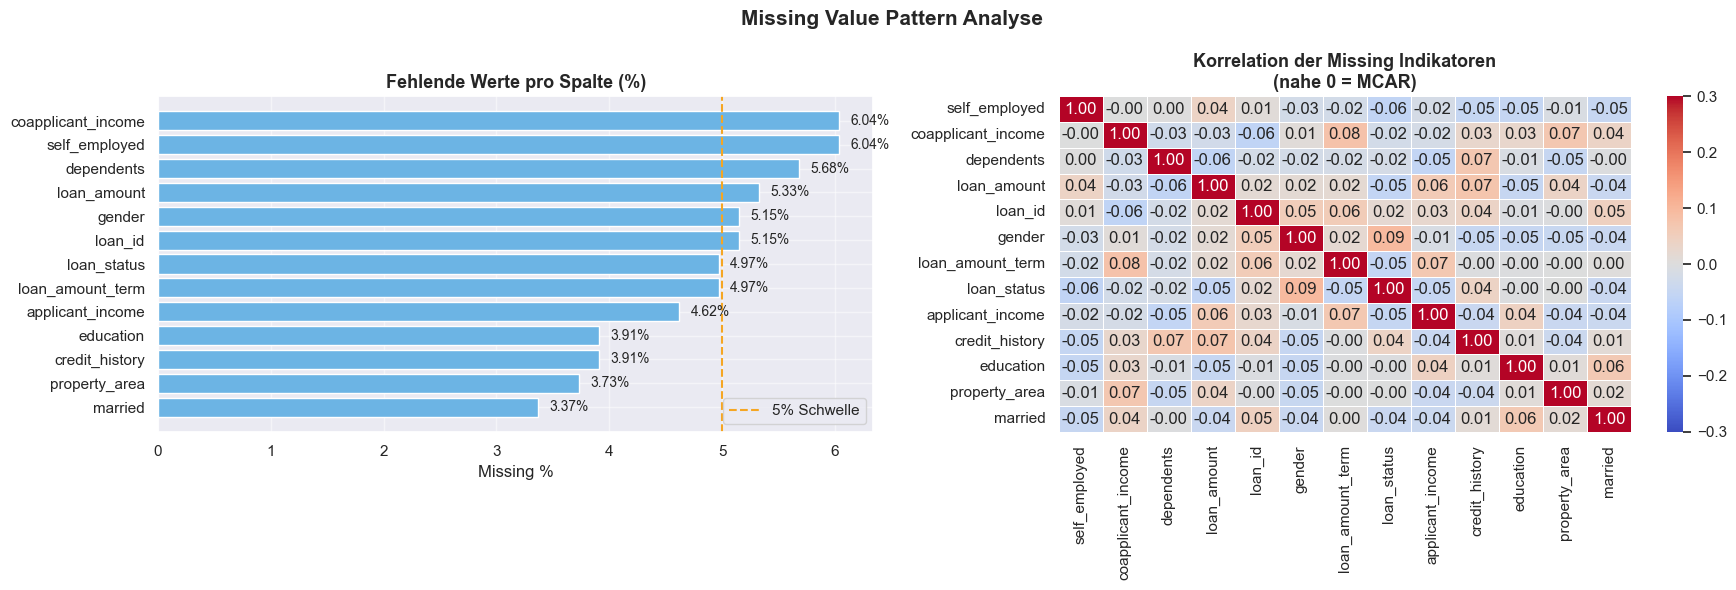

✅ Plot gespeichert: reports/figures/08_missing_pattern.png


In [20]:
# =============================================================================
# Zelle 18b – Missing Value Heatmap
# =============================================================================
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Missing Value Übersicht ---
ax1 = axes[0]
missing_pct = missing_stats["Missing %"].sort_values(ascending=True)
bars = ax1.barh(missing_pct.index, missing_pct.values, color="#6CB4E4")

# Werte annotieren
for bar, val in zip(bars, missing_pct.values):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=10)

ax1.set_title("Fehlende Werte pro Spalte (%)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Missing %")
ax1.axvline(x=5, color="#F5A623", linestyle="--", linewidth=1.5, label="5% Schwelle")
ax1.legend()

# --- Plot 2: Missing Korrelation Heatmap ---
ax2 = axes[1]
sns.heatmap(
    missing_corr_sub,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax2,
    vmin=-0.3,
    vmax=0.3
)
ax2.set_title("Korrelation der Missing Indikatoren\n(nahe 0 = MCAR)",
              fontsize=13, fontweight="bold")

plt.suptitle("Missing Value Pattern Analyse", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/08_missing_pattern.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/08_missing_pattern.png")

In [21]:
# =============================================================================
# Zelle 19 – Bivariate Analyse: Numerische Features
# Metriken: Pearson Korrelation, Point-Biserial, Mutual Information
# Ziel: Lineare UND nicht-lineare Zusammenhänge mit loan_status messen
# =============================================================================

num_cols = ["applicant_income", "coapplicant_income", "loan_amount",
            "loan_amount_term", "credit_history"]

# --- Datenbasis: nur vollständige Zeilen ---
df_clean = df[num_cols + ["loan_status"]].dropna()
X        = df_clean[num_cols]
y        = df_clean["loan_status"]

# --- Mutual Information ---
mi_scores = mutual_info_classif(X, y, random_state=42)

results = []

for i, col in enumerate(num_cols):
    # --- Pearson Korrelation (linear, Feature ↔ Target) ---
    pearson_r, pearson_p = stats.pearsonr(X[col], y)

    # --- Point-Biserial (korrekte Methode: numerisch ↔ binär) ---
    pb_r, pb_p = pointbiserialr(y, X[col])

    results.append({
        "Feature":              col,
        "Pearson r":            round(pearson_r, 4),
        "Pearson p":            round(pearson_p, 6),
        "Pearson signifikant?": "Ja" if pearson_p < 0.05 else "Nein",
        "Point-Biserial r":     round(pb_r, 4),
        "PB p-Wert":            round(pb_p, 6),
        "PB signifikant?":      "Ja" if pb_p < 0.05 else "Nein",
        "Mutual Information":   round(mi_scores[i], 4),
        "MI Rang":              0,  # wird danach berechnet
    })

df_biv_num = pd.DataFrame(results)

# --- MI Rang berechnen ---
df_biv_num["MI Rang"] = df_biv_num["Mutual Information"].rank(
    ascending=False).astype(int)

# --- Nach MI sortieren ---
df_biv_num = df_biv_num.sort_values("Mutual Information", ascending=False)

# --- CSV speichern ---
df_biv_num.to_csv("../reports/eda_csv/eda_bivariate_numeric.csv", index=False)

print("✅ CSV gespeichert: reports/eda_csv/eda_bivariate_numeric.csv\n")
pd.set_option("display.width", 200)
print(df_biv_num.to_string(index=False))

✅ CSV gespeichert: reports/eda_csv/eda_bivariate_numeric.csv

           Feature  Pearson r  Pearson p Pearson signifikant?  Point-Biserial r  PB p-Wert PB signifikant?  Mutual Information  MI Rang
    credit_history       0.45       0.00                   Ja              0.45       0.00              Ja                0.09        1
  applicant_income      -0.05       0.34                 Nein             -0.05       0.34            Nein                0.03        2
       loan_amount      -0.08       0.10                 Nein             -0.08       0.10            Nein                0.00        3
coapplicant_income      -0.10       0.05                   Ja             -0.10       0.05              Ja                0.00        4
  loan_amount_term       0.04       0.39                 Nein              0.04       0.39            Nein                0.00        4


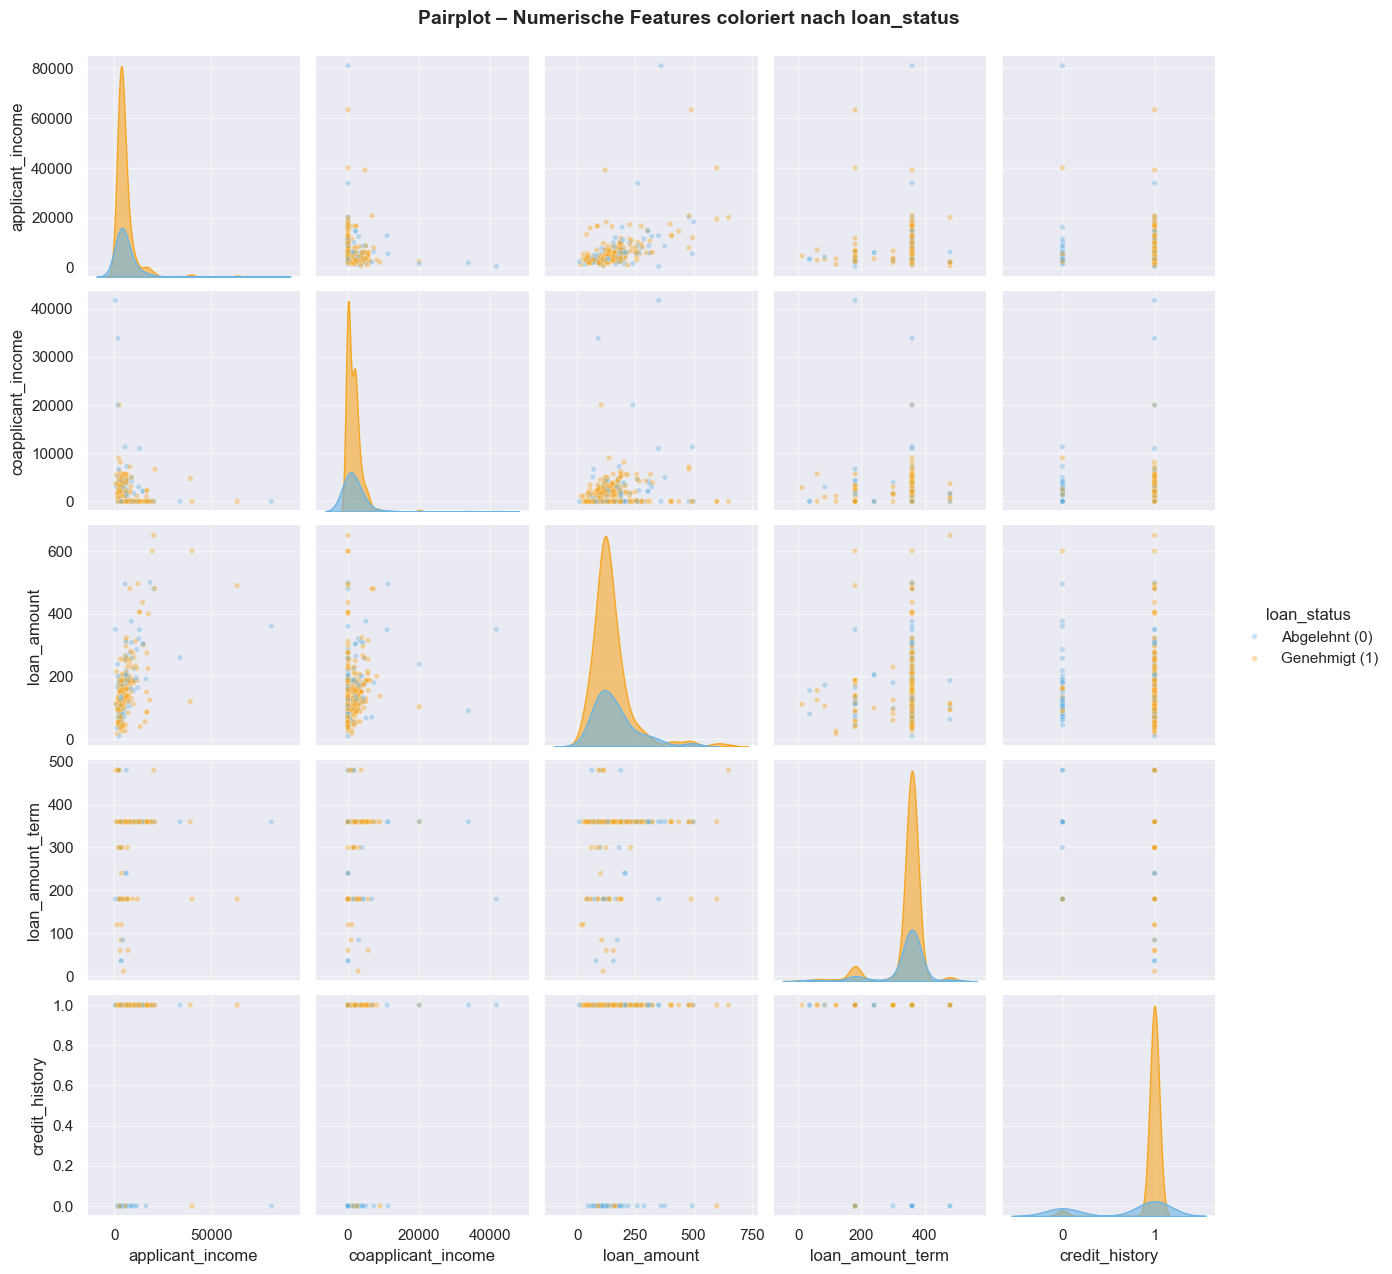

✅ Plot gespeichert: reports/figures/09_pairplot.png


In [22]:
# =============================================================================
# Zelle 20 – Pairplot: Alle numerischen Feature-Kombinationen
# Ziel: Multikollinearität, Cluster, nicht-lineare Strukturen visuell erkennen
# =============================================================================

num_cols_plot = ["applicant_income", "coapplicant_income", "loan_amount",
                 "loan_amount_term", "credit_history", "loan_status"]

df_pair = df[num_cols_plot].dropna()

# loan_status als Integer für saubere Farbgebung
df_pair = df_pair.copy()
df_pair["loan_status"] = df_pair["loan_status"].astype(int).astype(str)
df_pair["loan_status"] = df_pair["loan_status"].map({"0": "Abgelehnt (0)",
                                                      "1": "Genehmigt (1)"})

g = sns.pairplot(
    df_pair,
    hue="loan_status",
    palette={"Abgelehnt (0)": "#6CB4E4", "Genehmigt (1)": "#F5A623"},
    diag_kind="kde",        # Diagonale: KDE statt Histogramm
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kws={"alpha": 0.6}
)

g.figure.suptitle("Pairplot – Numerische Features coloriert nach loan_status",
                  fontsize=14, fontweight="bold", y=1.02)

plt.savefig("../reports/figures/09_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/09_pairplot.png")

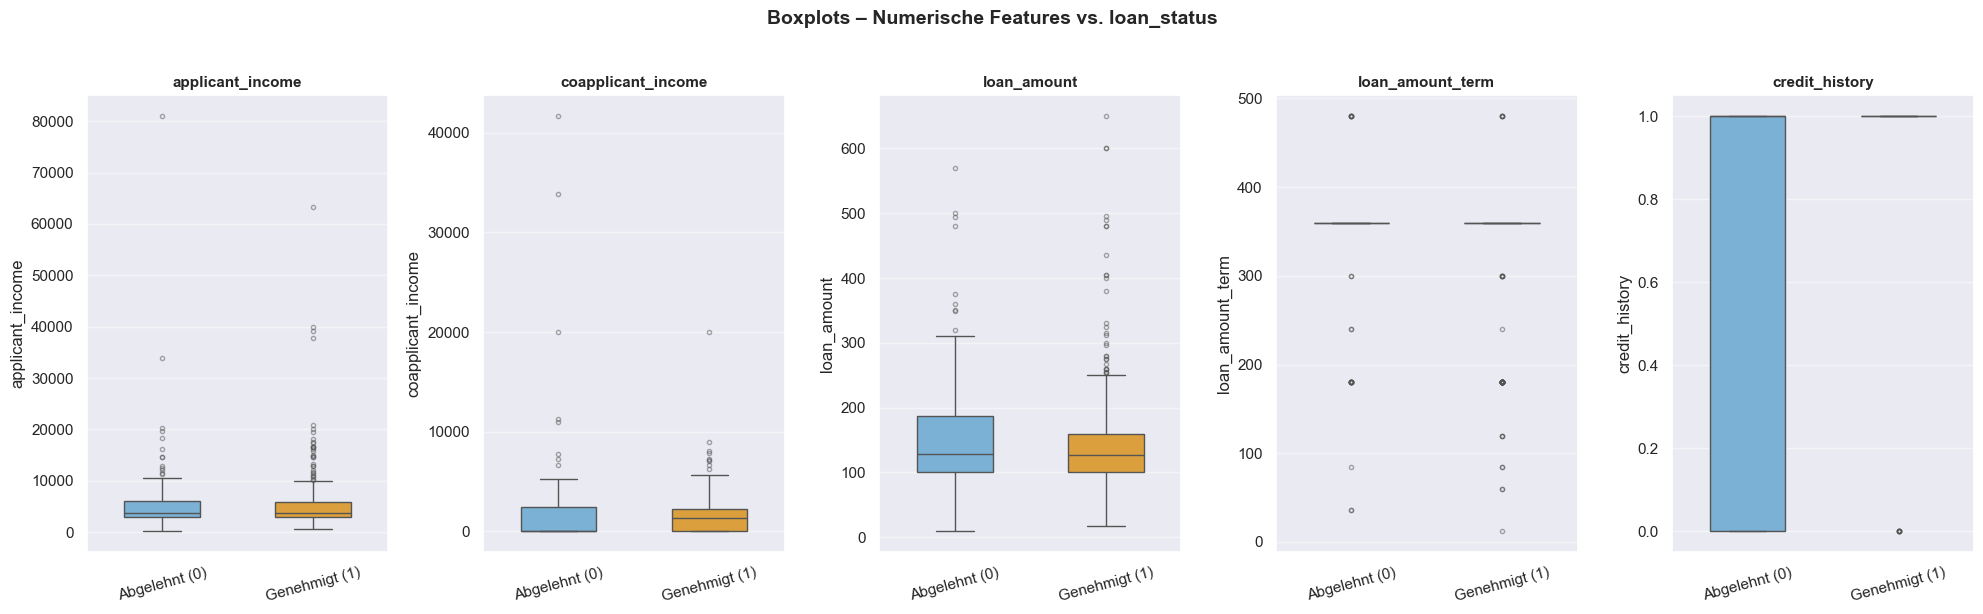

✅ Plot gespeichert: reports/figures/10_boxplots_vs_target.png
⚠️  loan_amount_term: IQR=0 – Outlier-Analyse übersprungen
⚠️  credit_history: IQR=0 – Outlier-Analyse übersprungen

✅ CSV gespeichert: reports/eda_csv/eda_outliers.csv
   Outlier gesamt: 96

=== Outlier pro Feature ===
                    N Outliers
Feature                       
applicant_income            43
coapplicant_income          17
loan_amount                 29


In [24]:
# =============================================================================
# Zelle 21 – Boxplots: Numerische Features vs. loan_status
#            + vollständige Outlier-Tabelle als CSV
# =============================================================================

num_cols = ["applicant_income", "coapplicant_income", "loan_amount",
            "loan_amount_term", "credit_history"]

# --- 21a: Boxplots (FutureWarning Fix: hue statt palette direkt) ---
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 6))

for ax, col in zip(axes, num_cols):
    temp = df[[col, "loan_status"]].dropna().copy()
    temp["loan_status_label"] = temp["loan_status"].map(
        {0.0: "Abgelehnt (0)", 1.0: "Genehmigt (1)"}
    )
    sns.boxplot(
        data=temp,
        x="loan_status_label",
        y=col,
        hue="loan_status_label",          # Fix FutureWarning
        palette={"Abgelehnt (0)": "#6CB4E4", "Genehmigt (1)": "#F5A623"},
        ax=ax,
        width=0.5,
        legend=False,                      # Fix FutureWarning
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.5}
    )
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Boxplots – Numerische Features vs. loan_status",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/10_boxplots_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/10_boxplots_vs_target.png")

# --- 21b: Outlier Tabelle ---
outlier_records = []

for col in num_cols:
    series = df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr

    # IQR=0 bei binären/konstanten Features überspringen
    if iqr == 0:
        print(f"⚠️  {col}: IQR=0 – Outlier-Analyse übersprungen")
        continue

    # Outlier-Zeilen extrahieren
    mask     = (df[col] < lower) | (df[col] > upper)
    outliers = df.loc[mask, ["loan_id", col, "loan_status"]].copy()
    outliers["Feature"]   = col
    outliers["IQR Lower"] = round(lower, 2)
    outliers["IQR Upper"] = round(upper, 2)
    outliers["Richtung"]  = np.where(df.loc[mask, col] > upper, "Oben", "Unten")
    outlier_records.append(outliers)

# --- Zusammenführen & Spalten ordnen ---
df_outliers = pd.concat(outlier_records, ignore_index=True)
df_outliers = df_outliers[["Feature", "loan_id", "loan_status",
                            "IQR Lower", "IQR Upper", "Richtung"] +
                           [c for c in df_outliers.columns
                            if c in num_cols]].copy()

# --- CSV speichern ---
df_outliers.to_csv("../reports/eda_csv/eda_outliers.csv", index=False)
print(f"\n✅ CSV gespeichert: reports/eda_csv/eda_outliers.csv")
print(f"   Outlier gesamt: {len(df_outliers)}")
print(f"\n=== Outlier pro Feature ===")
print(df_outliers.groupby("Feature")[["loan_id"]].count().rename(
    columns={"loan_id": "N Outliers"}))

✅ CSV gespeichert: reports/eda_csv/eda_cramersv_matrix.csv

=== Cramér's V Matrix ===
               gender  married  dependents  education  self_employed  property_area
gender           1.00     0.36        0.18       0.03           0.01           0.13
married          0.36     1.00        0.38       0.01           0.00           0.02
dependents       0.18     0.38        1.00       0.07           0.11           0.09
education        0.03     0.01        0.07       1.00           0.00           0.05
self_employed    0.01     0.00        0.11       0.00           1.00           0.04
property_area    0.13     0.02        0.09       0.05           0.04           1.00


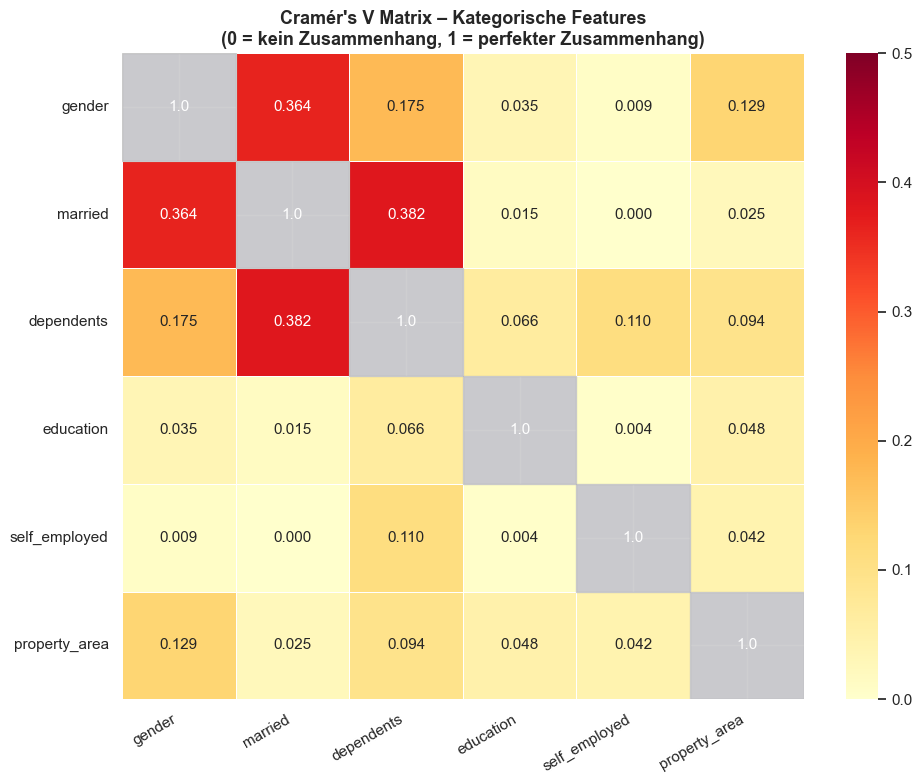

✅ Plot gespeichert: reports/figures/11_cramersv_matrix.png


In [25]:
# =============================================================================
# Zelle 22 – Cramér's V Matrix: Alle kategorischen Feature-Paare
# Ziel: Zusammenhänge zwischen kategorischen Features erkennen
#       (Multikollinearität bei kategorischen Features)
# =============================================================================

cat_cols = ["gender", "married", "dependents", "education",
            "self_employed", "property_area"]

def cramers_v_matrix(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Berechnet Cramér's V für alle Paare kategorischer Features.
    Symmetrische Matrix – V(A,B) = V(B,A)
    """
    matrix = pd.DataFrame(np.zeros((len(cols), len(cols))),
                          index=cols, columns=cols)
    for col1 in cols:
        for col2 in cols:
            if col1 == col2:
                matrix.loc[col1, col2] = 1.0
                continue
            # Nur vollständige Zeilen
            temp = df[[col1, col2]].dropna()
            confusion = pd.crosstab(temp[col1], temp[col2])
            chi2, _, _, _ = chi2_contingency(confusion)
            n = confusion.sum().sum()
            r, k = confusion.shape
            min_dim = min(r, k) - 1
            if min_dim == 0:
                matrix.loc[col1, col2] = 0.0
            else:
                v = np.sqrt(chi2 / (n * min_dim))
                matrix.loc[col1, col2] = round(v, 4)
    return matrix

# --- Matrix berechnen ---
cv_matrix = cramers_v_matrix(df, cat_cols)

# --- CSV speichern ---
cv_matrix.to_csv("../reports/eda_csv/eda_cramersv_matrix.csv")
print("✅ CSV gespeichert: reports/eda_csv/eda_cramersv_matrix.csv\n")
print("=== Cramér's V Matrix ===")
print(cv_matrix.to_string())

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(len(cat_cols), dtype=bool)  # Diagonale maskieren

sns.heatmap(
    cv_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    mask=mask,
    vmin=0,
    vmax=0.5,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 11}
)

# Diagonale manuell auf grau setzen
for i in range(len(cat_cols)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1,
                 fill=True, color="#AAAAAA", alpha=0.5))
    ax.text(i + 0.5, i + 0.5, "1.0",
            ha="center", va="center", fontsize=11, color="white")

ax.set_title("Cramér's V Matrix – Kategorische Features\n"
             "(0 = kein Zusammenhang, 1 = perfekter Zusammenhang)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../reports/figures/11_cramersv_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/11_cramersv_matrix.png")

In [26]:
# =============================================================================
# Zelle 23 – Kruskal-Wallis Test: Numerisch vs. Kategorisch
# Ziel: Unterscheiden sich numerische Features signifikant
#       zwischen den Gruppen kategorischer Features?
# Kruskal-Wallis = non-parametrische Alternative zu ANOVA
# Vorteil: keine Normalverteilung vorausgesetzt (hier korrekt – SW Test = Nein)
# =============================================================================

num_cols = ["applicant_income", "coapplicant_income", "loan_amount",
            "loan_amount_term", "credit_history"]

cat_cols = ["gender", "married", "dependents", "education",
            "self_employed", "property_area"]

results = []

for cat in cat_cols:
    for num in num_cols:
        # Nur vollständige Zeilen
        temp = df[[cat, num]].dropna()

        # Gruppen erstellen – eine Liste pro Kategorie
        groups = [
            temp.loc[temp[cat] == cat_val, num].values
            for cat_val in temp[cat].unique()
        ]

        # Mindestens 2 Gruppen mit je mind. 5 Werten
        groups = [g for g in groups if len(g) >= 5]
        if len(groups) < 2:
            continue

        # --- Kruskal-Wallis Test ---
        stat, p_val = kruskal(*groups)

        # --- Effektgröße: Eta-Squared (η²) ---
        # η² = (H - k + 1) / (n - k)
        # H = Kruskal-Wallis Statistik, k = Anzahl Gruppen, n = Gesamtgröße
        n = sum(len(g) for g in groups)
        k = len(groups)
        eta_sq = (stat - k + 1) / (n - k)
        eta_sq = max(0, round(eta_sq, 4))  # Negativ auf 0 clippen

        results.append({
            "Kategorisches Feature": cat,
            "Numerisches Feature":   num,
            "N Gruppen":             k,
            "N Total":               n,
            "Kruskal-Wallis H":      round(stat, 4),
            "p-Wert":                round(p_val, 6),
            "Signifikant? (p<0.05)": "Ja" if p_val < 0.05 else "Nein",
            "Eta-Squared (η²)":      eta_sq,
            "Effektgröße":          ("Groß"   if eta_sq > 0.14 else
                                     "Mittel" if eta_sq > 0.06 else
                                     "Klein"  if eta_sq > 0.01 else
                                     "Minimal"),
        })

df_kruskal = pd.DataFrame(results)
df_kruskal = df_kruskal.sort_values("p-Wert")

# --- CSV speichern ---
df_kruskal.to_csv("../reports/eda_csv/eda_kruskal_wallis.csv", index=False)
print("✅ CSV gespeichert: reports/eda_csv/eda_kruskal_wallis.csv\n")

# --- Ausgabe: nur signifikante Ergebnisse ---
print("=== Signifikante Ergebnisse (p < 0.05) ===")
sig = df_kruskal[df_kruskal["Signifikant? (p<0.05)"] == "Ja"]
print(sig.to_string(index=False))

print(f"\n=== Alle Ergebnisse ({len(df_kruskal)} Paare) ===")
print(df_kruskal.to_string(index=False))

✅ CSV gespeichert: reports/eda_csv/eda_kruskal_wallis.csv

=== Signifikante Ergebnisse (p < 0.05) ===
Kategorisches Feature Numerisches Feature  N Gruppen  N Total  Kruskal-Wallis H  p-Wert Signifikant? (p<0.05)  Eta-Squared (η²) Effektgröße
               gender  coapplicant_income          2      502             25.82    0.00                    Ja              0.05       Klein
              married  coapplicant_income          2      512             33.47    0.00                    Ja              0.06      Mittel
        self_employed    applicant_income          2      504             28.26    0.00                    Ja              0.05       Klein
               gender         loan_amount          2      506             18.21    0.00                    Ja              0.03       Klein
              married         loan_amount          2      514             16.41    0.00                    Ja              0.03       Klein
            education         loan_amount          2      

In [28]:
# =============================================================================
# Zelle 24 – EDA Summary als Markdown-Datei generieren
# Speicherort: reports/eda_summary.md
# =============================================================================

summary = """# EDA Summary – Loan Status Klassifikation
**Projekt:** MSIT Mock Interview
**Notebook:** 01_eda.ipynb
**Datensatz:** loans_modified.csv – 563 Zeilen, 13 Spalten
**Zielvariable:** loan_status (binär: 0 = Abgelehnt, 1 = Genehmigt)

---

## 1. Datensatz-Übersicht

| Merkmal | Wert |
|---------|------|
| Zeilen gesamt | 563 |
| Spalten gesamt | 13 |
| Numerische Features | 5 |
| Kategorische Features | 6 |
| ID-Spalte | loan_id |
| Zielvariable | loan_status |

---

## 2. Fehlende Werte

### Befund
- **Alle 13 Spalten** haben fehlende Werte (3.4% – 6.0%)
- Kein Feature überschreitet 10% → kein Feature wird entfernt
- **MCAR bestätigt** – Missing Indikator Korrelationen alle nahe 0
- Fehlende Werte entstehen zufällig – Imputation statistisch vertretbar

### Strategie
| Feature | Typ | Strategie |
|---------|-----|-----------|
| `loan_status` | Zielvariable | Zeilen entfernen |
| `loan_id` | ID | Zeilen entfernen |
| `applicant_income`, `coapplicant_income`, `loan_amount`, `loan_amount_term` | Numerisch | Median |
| `gender`, `married`, `dependents`, `education`, `self_employed`, `property_area` | Kategorisch | Modus |
| `credit_history` | Binär | Modus |

---

## 3. Zielvariable – Klassenungleichgewicht

| Klasse | N | % |
|--------|---|---|
| 1 – Genehmigt | 384 | 71.78% |
| 0 – Abgelehnt | 151 | 28.22% |

**Klassenungleichgewicht: 2.54:1**

### Konsequenzen
- `Accuracy` als Metrik ungeeignet – Baseline 71.78% ohne Lernen erreichbar
- Metriken: F1-Score, ROC-AUC, Precision-Recall AUC, Matthews Correlation Coefficient
- Modellseitig: `class_weight='balanced'` oder SMOTE evaluieren

---

## 4. Numerische Features – Univariate Analyse

### Verteilung & Transformation
| Feature | Skewness | Kurtosis | Normalverteilt? | Transformation |
|---------|----------|----------|-----------------|---------------|
| `applicant_income` | 6.74 | 65.34 | Nein | Yeo-Johnson ✅ |
| `coapplicant_income` | 7.30 | 78.20 | Nein | Yeo-Johnson + Binary Feature ✅ |
| `loan_amount` | 2.43 | 8.36 | Nein | Yeo-Johnson ✅ |
| `loan_amount_term` | -2.43 | 6.82 | Nein | Binary Feature (is_standard_term) |
| `credit_history` | -2.32 | 3.38 | Nein | Keine – bleibt binär |

### Ausreißer (IQR-Methode)
| Feature | N Outliers | % |
|---------|-----------|---|
| `applicant_income` | 43 | 8.0% |
| `loan_amount` | 29 | 5.4% |
| `coapplicant_income` | 17 | 3.2% |
| `loan_amount_term` | übersprungen (IQR=0) | – |
| `credit_history` | übersprungen (IQR=0) | – |

**Strategie:** Transformation statt Entfernung – reale Werte, kein Datenverlust

---

## 5. Kategorische Features – Univariate Analyse

### Zusammenhang mit loan_status (Cramér's V + Chi²)
| Feature | Cramér's V | Chi² p | Assoziation | Unabhängig? |
|---------|-----------|--------|-------------|-------------|
| `property_area` | 0.157 | 0.002 | Moderat | Nein ✅ |
| `married` | 0.090 | 0.041 | Schwach | Nein ✅ |
| `dependents` | 0.071 | 0.473 | Schwach | Ja |
| `self_employed` | 0.035 | 0.435 | Schwach | Ja |
| `education` | 0.034 | 0.443 | Schwach | Ja |
| `gender` | 0.008 | 0.853 | Keine | Ja |

### Genehmigungsrate pro Gruppe
| Feature | Stärkste Gruppe | Rate | Schwächste Gruppe | Rate | Δ |
|---------|----------------|------|-------------------|------|---|
| `property_area` | Semiurban | 81.4% | Rural | 65.3% | 16.1% |
| `married` | Yes | 75.3% | No | 66.5% | 8.8% |
| `dependents` | 2 | 78.1% | 1 | 67.8% | 10.3% |
| `education` | Graduate | 72.1% | Not Graduate | 67.9% | 4.3% |
| `self_employed` | No | 72.8% | Yes | 67.2% | 5.6% |
| `gender` | Male | 72.3% | Female | 70.7% | 1.6% |

---

## 6. Bivariate Analyse – Numerisch vs. loan_status

### Pearson / Point-Biserial / Mutual Information
| Feature | Pearson r | MI | Signifikant? |
|---------|-----------|-----|-------------|
| `credit_history` | 0.45 | 0.09 | Ja ✅ |
| `coapplicant_income` | -0.10 | 0.00 | Ja (knapp) |
| `loan_amount` | -0.08 | 0.00 | Nein |
| `applicant_income` | -0.05 | 0.03 | Nein |
| `loan_amount_term` | 0.04 | 0.00 | Nein |

**Befund:** `credit_history` einziger starker numerischer Prädiktor.
Alle anderen numerischen Features zeigen schwache lineare und nicht-lineare Zusammenhänge.

---

## 7. Kategorische Multikollinearität (Cramér's V Matrix)

| Paar | V | Bewertung |
|------|---|-----------|
| `married` ↔ `dependents` | 0.382 | ⚠️ Stark |
| `gender` ↔ `married` | 0.364 | ⚠️ Stark |
| `gender` ↔ `dependents` | 0.175 | Moderat |

**Konsequenz:** Features vorerst behalten – Feature Importance entscheidet final.

---

## 8. Kruskal-Wallis – Numerisch vs. Kategorisch

**Einziger mittlerer Effekt:**
- `married` ↔ `coapplicant_income` (η²=0.06) – Verheiratete haben höheres Co-Einkommen

**Alle anderen Effekte:** Klein bis minimal – kategorische Features erklären numerische kaum.

**`credit_history` vollständig unabhängig** von allen kategorischen Features (p > 0.59).

---

## 9. Gesamtbefund & Feature-Ranking

| Rang | Feature | Typ | Stärke | Basis |
|------|---------|-----|--------|-------|
| 1 | `credit_history` | Numerisch/Binär | ⭐⭐⭐⭐⭐ | Pearson 0.45, MI 0.09, Genehmigungsrate Δ67% |
| 2 | `property_area` | Kategorisch | ⭐⭐⭐ | Cramér's V 0.157, Δ16.1% |
| 3 | `married` | Kategorisch | ⭐⭐ | Cramér's V 0.090, Δ8.8% |
| 4 | `dependents` | Kategorisch | ⭐⭐ | Genehmigungsrate Δ10.3% |
| 5 | `applicant_income` | Numerisch | ⭐ | MI 0.03, schwach nicht-linear |
| 6 | `coapplicant_income` | Numerisch | ⭐ | Pearson -0.10 |
| 7 | `education` | Kategorisch | ⭐ | Cramér's V 0.034 |
| 8 | `loan_amount` | Numerisch | ⭐ | Pearson -0.08 |
| 9 | `self_employed` | Kategorisch | ⭐ | Cramér's V 0.035 |
| 10 | `loan_amount_term` | Numerisch | ✗ | MI 0.00, Pearson 0.04 |
| 11 | `gender` | Kategorisch | ✗ | Cramér's V 0.008, Δ1.6% |

---

## 10. Entscheidungen für 02_preprocessing.ipynb

### Fehlende Werte
- `loan_status` NaN → Zeilen entfernen
- `loan_id` NaN → Zeilen entfernen
- Numerische Features → Median Imputation
- Kategorische Features → Modus Imputation

### Transformationen
- `applicant_income` → Yeo-Johnson
- `coapplicant_income` → Yeo-Johnson + neues Feature `has_coapplicant` (0/1)
- `loan_amount` → Yeo-Johnson
- `loan_amount_term` → neues Feature `is_standard_term` (1 wenn 360, sonst 0)
- `credit_history` → keine Transformation

### Feature Engineering
- `has_coapplicant`: 1 wenn coapplicant_income > 0, sonst 0
- `is_standard_term`: 1 wenn loan_amount_term == 360, sonst 0
- `total_income`: applicant_income + coapplicant_income (vor Transformation)

### Encoding
- Binäre Features (`gender`, `married`, `education`, `self_employed`) → Label Encoding
- `dependents` → Ordinales Encoding (0, 1, 2, 3+ → 0, 1, 2, 3)
- `property_area` → One-Hot Encoding (3 Kategorien)

### Feature Removal Kandidaten
- `loan_id` → ID, kein Prädiktor
- `gender` → Cramér's V 0.008, statistisch irrelevant (finale Entscheidung nach Feature Importance)
- `loan_amount_term` → MI 0.00, wird durch `is_standard_term` ersetzt

### Skalierung
- StandardScaler für lineare Modelle (Logistic Regression, SVM)
- Baumbasierte Modelle (Random Forest, XGBoost) → keine Skalierung nötig

---

## 11. Theoretische Grenzen dieser EDA

| Grenze | Detail |
|--------|--------|
| Pearson nur linear | Nicht-lineare Zusammenhänge unsichtbar |
| Cramér's V nur bivariat | Interaktionen zwischen 3+ Features nicht erfasst |
| Kleine Stichprobe (n=563) | Statistische Tests instabil bei seltenen Kategorien |
| Klassenungleichgewicht | Alle Metriken leicht verzerrt Richtung Mehrheitsklasse |
| Kruskal-Wallis kein Post-hoc | Paarweise Gruppenunterschiede nicht identifiziert |

---

*Erstellt: 01_eda.ipynb – MSIT Mock Interview | 2026*
"""

# --- Datei speichern ---
with open("../reports/eda_summary.md", "w", encoding="utf-8") as f:
    f.write(summary)

print("✅ EDA Summary gespeichert: reports/eda_summary.md")

✅ EDA Summary gespeichert: reports/eda_summary.md
